## Performance of NMWI


In [1]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import glob, warnings, sys, runpy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut, GridSearchCV, RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import balanced_accuracy_score, recall_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message="pkg_resources is deprecated as an API")


In [2]:
# Run only once to get the working directory
project_root = Path("../../").resolve()
os.chdir(project_root)
print("Working dir:", Path.cwd())

Working dir: /Users/barrera.maria/Library/CloudStorage/GoogleDrive-barrera.maria1297@gmail.com/.shortcut-targets-by-id/1LkgWZVWWAMM27iFYdRSBNH8E7w0EPw9j/Maria B/Final_Codes


In [3]:
%matplotlib inline
# METADATA LOADING
vars_dict = runpy.run_path("Codes/Auxiliary_files/Generate_data_index.py")
globals().update(vars_dict)

Found 28 genus tables in index
Removed 4 OTU IDs listed in OTU_IDS_TO_EXCLUDE
Number of samples: 1807, and number of taxa: 294
Number of unique studies: 28

Sample_id per Category:
Category  n_sample_id
    case         1122
 control          685


- X: DataFrame (rows=samples, cols=taxonomy), index includes bioproject/sample_id RELATIVE ABUNDANCE
- y: Series/array-like of True/False (same index as X), True (1) =control, False=case

In [4]:
X_new = X.copy()

## Hyperparameters search

In [356]:
# extra
warnings.filterwarnings("ignore", message="pkg_resources is deprecated as an API")

# --------------------------------------------------
# LOSO GRID SEARCH FOR BEST C
# --------------------------------------------------

# Base parameters shared by all models
model_params = dict(
    random_state=42,
    penalty="l1",
    solver="liblinear",
    class_weight="balanced",
    max_iter=2000
)

# Grid search for parameters
C_grid = np.arange(0.0025, 4.0025, 0.0025)

# Groups for LOSO
bio_ids = np.array(X_new.index.get_level_values(0))
loso = LeaveOneGroupOut()

X_arr = X_new
y_arr = y.values.ravel()

loso_results = []
loso_scores = np.full(len(y), np.nan)

for C_val in C_grid:
    fold_bas = []

    for train_idx, test_idx in loso.split(X_arr, y_arr, groups=bio_ids):
        X_tr = X_arr.iloc[train_idx]
        X_te = X_arr.iloc[test_idx]
        y_tr = y_arr[train_idx]
        y_te = y_arr[test_idx]

        model = LogisticRegression(**model_params, C=C_val)
        model.fit(X_tr, y_tr)

        loso_scores[test_idx] = model.decision_function(X_te)

        y_hat = model.predict(X_te)
        ba = balanced_accuracy_score(y_te, y_hat)
        fold_bas.append(ba)

    mean_loso_ba = np.mean(fold_bas)

    loso_results.append({
        "C": C_val,
        "mean_LOSO_BA": mean_loso_ba
    })



AttributeError: 'float' object has no attribute 'values'

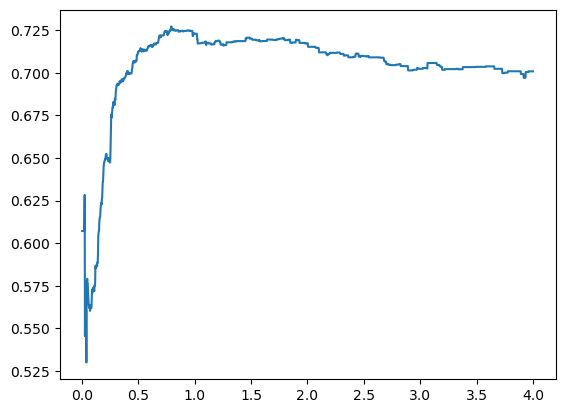

In [21]:
loso_results = pd.DataFrame(loso_results)
loso_grid_df = pd.DataFrame(loso_results.sort_values("mean_LOSO_BA", ascending=False))

# Best C according to LOSO, skipping excluded mean_LOSO_BA
C = loso_grid_df.iloc[0]["C"]
best_loso_score = loso_grid_df.iloc[0]["mean_LOSO_BA"]
plt.plot(loso_results['C'],loso_results['mean_LOSO_BA'])

In [22]:
print(f'Best regularization parameters: {C}')

Best regularization parameters: 0.795


## NMWI FINAL MODEL

In [8]:
%%writefile Codes/Auxiliary_files/NMWI.py
# This code is saved into a script. 

C = 0.795 # Best regularization parameters for relative abundance

final_params = dict(
    random_state=42,
    penalty="l1",
    solver="liblinear",
    class_weight="balanced",
    C=C,
    max_iter=2000
)

NMWI = LogisticRegression(**final_params)
NMWI.fit(X_new, y.values)

y_train_pred = NMWI.predict(X_new)
scores_all = NMWI.decision_function(X_new)
train_bal_acc = balanced_accuracy_score(y.values, y_train_pred)

coef = NMWI.coef_.flatten()
feature_names = X_new.columns

coefficients = pd.DataFrame(coef, index=feature_names, columns=["Coefficient"])
sorted_coefficients = coefficients.sort_values("Coefficient", ascending=False)
NMWI_coefs = sorted_coefficients[(sorted_coefficients['Coefficient']>0) | (sorted_coefficients['Coefficient']<0)]
NMWI_coefs.reset_index().to_csv('NMWI_coefficients.csv')

num_pos  = (sorted_coefficients["Coefficient"] > 0).sum()
num_neg  = (sorted_coefficients["Coefficient"] < 0).sum()
num_zero = (sorted_coefficients["Coefficient"] == 0).sum()
num_coef = len(sorted_coefficients)

# 10 x 10 CV
y_arr = y.values.ravel()

model_10x10 = LogisticRegression(**final_params)

cv = RepeatedStratifiedKFold(n_splits=10, 
                             n_repeats=10, 
                             random_state=42) 

cv_splits = []
cv_splits = list(cv.split(X_new, y_arr))

scores = cross_val_score(
    estimator=model_10x10,
    X=X_new,
    y=y.values,
    cv=cv,
    scoring='balanced_accuracy',
    n_jobs=-1
)

print('NMWI fitted; 10x10cv')

Overwriting Codes/Auxiliary_files/NMWI.py


In [9]:
%run -i Codes/Auxiliary_files/NMWI.py # Run model

NMWI fitted; 10x10cv


In [ ]:
# # TEST individually 
# X_test = X_new[X_new.index.get_level_values('BioProject.Number')== 'PRJEB22676']
# y_test = y[y.index.get_level_values('BioProject.Number')== 'PRJEB22676']

# X_train = X_new[X_new.index.get_level_values('BioProject.Number') != 'PRJEB22676']
# y_train = y[y.index.get_level_values('BioProject.Number') != 'PRJEB22676']

# final_params = dict(
#     random_state=42,
#     penalty="l1",
#     solver="liblinear",
#     class_weight="balanced",
#     C=C,
#     max_iter=2000
# )
# model_test = LogisticRegression(**final_params)
# model_test.fit(X_train, y_train)

# y_test_hat = model_test.predict(X_test)
# ba_test = balanced_accuracy_score(y_test, y_test_hat) 

# coef_2 = model_test.coef_.flatten()
# feature_names = X_new.columns

# coefficients_test = pd.DataFrame(coef_2, index=feature_names, columns=["Coefficient"])

# intercept = model.intercept_

# ####Manual
# df1 = X_test[X_test.index.get_level_values(1)=='ERR1662647']
# df2 = coefficients_test
# print((df1.T.to_numpy() * df2.to_numpy()).sum() + intercept)

# # model
# print(model_test.decision_function(df1))

### Coefficients

In [18]:
# sorted_coefficients[(sorted_coefficients['Coefficient']>0) | (sorted_coefficients['Coefficient']<0)].to_csv('Additional_file_3.csv')
sorted_coefficients[(sorted_coefficients['Coefficient']>0) | (sorted_coefficients['Coefficient']<0)]


,Coefficient
d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides,12.069390
d__Bacteria;p__Actinobacteriota;c__Actinobacteria;o__Corynebacteriales;__;__,5.096829
d__Bacteria;p__Actinobacteriota;c__Actinobacteria;o__Corynebacteriales;f__Corynebacteriaceae;__,4.609802
d__Bacteria;p__Actinobacteriota;c__Actinobacteria;o__Propionibacteriales;f__Propionibacteriaceae;g__Cutibacterium,4.155825
d__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Burkholderiales;f__Burkholderiaceae;g__Ralstonia,3.772718
d__Bacteria;p__Bacteroidota;c__Bacteroidia;__;__;__,2.155787
d__Bacteria;p__Actinobacteriota;c__Actinobacteria;__;__;__,1.497954
d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Carnobacteriaceae;g__Dolosigranulum,1.167435
d__Bacteria;p__Firmicutes;c__Bacilli;__;__;__,1.129338
d__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Burkholderiales;__;__,1.094514


## LOSO

In [19]:
%%writefile Codes/Auxiliary_files/LOSO.py
# This code is saved into a script. 

# --------------------------------------------------
# PER-FOLD LOSO PERFORMANCE USING BEST C
# --------------------------------------------------

fold_bas = []
loso_loop = []
coef_rows = []
selected_sets = []
loso = LeaveOneGroupOut()
loso_scores = np.full(len(y), np.nan)

bio_ids = np.array(X_new.index.get_level_values(0))
y_arr = y.values.ravel()

bio_ids_arr = np.asarray(bio_ids)
fold_sizes = []
for train_idx, test_idx in loso.split(X_new, y_arr, groups=bio_ids):
    X_tr = X_new.iloc[train_idx]
    X_te = X_new.iloc[test_idx]
    y_tr = y_arr[train_idx]
    y_te = y_arr[test_idx]

    model = LogisticRegression(**final_params)
    model.fit(X_tr, y_tr)
    loso_scores[test_idx] = model.decision_function(X_te)

    y_hat = model.predict(X_te)
    ba = balanced_accuracy_score(y_te, y_hat)
    fold_bas.append(ba)
    fold_sizes.append(len(test_idx))

    proj_te = pd.Index(bio_ids_arr[test_idx]).unique().tolist()[0]

    loso_loop.append({
        "BioProject": proj_te,
        "n_test": len(test_idx),
        "pos_test": int(y_te.sum()),
        "neg_test": int((y_te == 0).sum()),
        "BA": ba
    })

    coefs = model.coef_.ravel()
    fold_name = pd.Index(bio_ids_arr[test_idx]).unique().tolist()[0]
    row = pd.Series(coefs, index=feature_names, name=fold_name)
    coef_rows.append(row)

    selected_sets.append(set(np.array(feature_names)[coefs != 0]))
    

coef_df = pd.DataFrame(coef_rows)
loso_df = pd.DataFrame(loso_loop).sort_values("BA")
mean_cv_ba = float(np.mean(fold_bas)) if fold_bas else np.nan

Overwriting Codes/Auxiliary_files/LOSO.py


In [20]:
%run -i Codes/Auxiliary_files/LOSO.py # Run model

### Figure 2a

In [21]:
temp_coef = sorted_coefficients.copy()
temp_coef['order'] = np.arange(1,295,1)

## Frequency selection
sel_freq = (coef_df != 0).sum(axis=0) / coef_df.shape[0] 
coef_for_color = temp_coef["Coefficient"].copy()

plot_freq = pd.DataFrame({
    "feature": coef_for_color.index,
    "coef": coef_for_color.values,
    "sel_freq": sel_freq.reindex(coef_for_color.index).fillna(0).values,
    'order': temp_coef['order'].reindex(coef_for_color.index)
})

plot_freq = plot_freq[(plot_freq["coef"] > 0)|(plot_freq["coef"] < 0)]
plot_freq

,feature,coef,sel_freq,order
d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...,12.069390,0.964286,1
d__Bacteria;p__Actinobacteriota;c__Actinobacteria;o__Corynebacteriales;__;__,d__Bacteria;p__Actinobacteriota;c__Actinobacte...,5.096829,1.000000,2
d__Bacteria;p__Actinobacteriota;c__Actinobacteria;o__Corynebacteriales;f__Corynebacteriaceae;__,d__Bacteria;p__Actinobacteriota;c__Actinobacte...,4.609802,1.000000,3
d__Bacteria;p__Actinobacteriota;c__Actinobacteria;o__Propionibacteriales;f__Propionibacteriaceae;g__Cutibacterium,d__Bacteria;p__Actinobacteriota;c__Actinobacte...,4.155825,1.000000,4
d__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Burkholderiales;f__Burkholderiaceae;g__Ralstonia,d__Bacteria;p__Proteobacteria;c__Gammaproteoba...,3.772718,1.000000,5
d__Bacteria;p__Bacteroidota;c__Bacteroidia;__;__;__,d__Bacteria;p__Bacteroidota;c__Bacteroidia;__;...,2.155787,0.964286,6
d__Bacteria;p__Actinobacteriota;c__Actinobacteria;__;__;__,d__Bacteria;p__Actinobacteriota;c__Actinobacte...,1.497954,0.964286,7
d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Carnobacteriaceae;g__Dolosigranulum,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactob...,1.167435,1.000000,8
d__Bacteria;p__Firmicutes;c__Bacilli;__;__;__,d__Bacteria;p__Firmicutes;c__Bacilli;__;__;__,1.129338,0.964286,9
d__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Burkholderiales;__;__,d__Bacteria;p__Proteobacteria;c__Gammaproteoba...,1.094514,0.964286,10


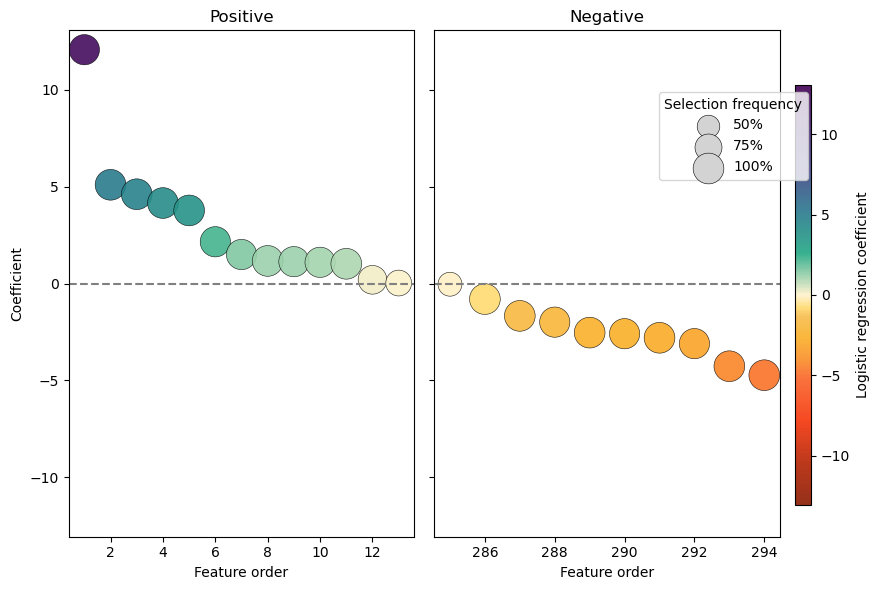

In [25]:
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap

y_max = abs(plot_freq['coef']).max() + 1

norm = TwoSlopeNorm(vmin=-y_max, vcenter=0, vmax=y_max)

cmap_custom = LinearSegmentedColormap.from_list(
    "purple_zero_yellow_red_neg",
    [
        (0.00, "#8a1a01"), # Lowest
        (0.10, "#b52302"),
        (0.20, "#f5350a"),
        (0.30, "#fa6328"),
        (0.35, "#fa9128"),
        (0.40, "#fab028"),
        (0.45, "#f7bc4d"),
        (0.47, "#ffdb70"),
        (0.50, "#fff2cc"), # zero
        (0.60, "#22A884"),
        (0.70, "#2A788E"),
        (0.80, "#414487"),
        (1.00, "#440154"),
    ],
    N=256,
)

df_pos = plot_freq[plot_freq['coef'] > 0]
df_neg = plot_freq[plot_freq['coef'] < 0]

fig, axes = plt.subplots(1, 2, figsize=(8, 6), sharey=True)
fig.subplots_adjust(right=5)

axes[0].scatter(
    df_pos['order'],
    df_pos['coef'],
    s=40 + 450 * df_pos['sel_freq'],
    edgecolor="black",
    linewidth=0.4,
    alpha=0.9,
    c=df_pos["coef"],
    norm=norm,
    cmap=cmap_custom
)

axes[0].axhline(0, color='gray', linestyle='--')
axes[0].set_xlabel("Feature order")
axes[0].set_ylabel("Coefficient")
axes[0].set_title("Positive")
axes[0].set_ylim(-y_max, y_max)

sc= axes[1].scatter(
    df_neg['order'],
    df_neg['coef'],
    s=40 + 450 * df_neg['sel_freq'],
    edgecolor="black",
    linewidth=0.4,
    alpha=0.9,
    c=df_neg["coef"],
    norm=norm,
    cmap=cmap_custom
)

axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_xlabel("Feature order")
axes[1].set_title("Negative")
axes[1].set_ylim(-y_max, y_max)

cax = fig.add_axes([1, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(sc, cax=cax)
cbar.set_label("Logistic regression coefficient")

size_levels = [0.50, 0.75, 1.00]
handles = [
    plt.scatter([], [], s=40 + 450*s, facecolor="lightgray", edgecolor="black", linewidth=0.4)
    for s in size_levels
]
labels = [f"{int(s*100)}%" for s in size_levels]

plt.legend(
    handles, labels,
    title="Selection frequency",
    loc="upper right",
    bbox_to_anchor=(1.25, 1.0),
    frameon=True
)

plt.tight_layout()
plt.savefig("Figures/Fig2a.pdf")
plt.show()


In [34]:
import matplotlib
matplotlib.use("cairo")
import matplotlib.pyplot as plt

# Heatmap
pos_feats = df_pos.index.to_list()
neg_feats = df_neg.index.to_list()
feature_order = list(dict.fromkeys(pos_feats + neg_feats))
heat = coef_df[feature_order].T

# Order studies by total absolute coefficient magnitude
group_order = coef_df[feature_order].abs().sum(axis=1).sort_values(ascending=False).index
heat = heat[group_order]

fig_h = max(8, int(0.28 * heat.shape[0]))
fig_w = max(12, int(0.6 * heat.shape[1]))


plt.figure(figsize=(fig_w, fig_h))
sns.heatmap(
    heat,
    cmap=cmap_custom,
    norm = norm,
    linewidths=0.05,
    linecolor="lightgray",
    cbar_kws={"label": "Logistic regression coefficient"},
)

plt.xlabel("Held-out LOSO group (BioProject)")
plt.ylabel("Top features")
plt.title("LOSO Coefficient Heatmap")
plt.tight_layout()
plt.savefig("Figures/Fig2b.pdf")
plt.show()

In [35]:
from matplotlib.colors import ListedColormap

zero_map = (heat == 0)

plt.figure(figsize=(fig_w, fig_h))
sns.heatmap(
    zero_map,
    cmap=ListedColormap(["white", "black"]),
    linewidths=0.05,
    linecolor="lightgray",
    cbar=False
)

plt.xlabel("Held-out LOSO group (BioProject)")
plt.ylabel("Top features")
plt.title("Zero vs non-zero coefficients")
plt.tight_layout()
plt.savefig("Figures/Fig2b_1.pdf")
plt.show()
